# European Port Traffic — Eurostat Data Exploration

First step of a project to **predict port traffic and load balance** across European ports.

**Dataset:** Eurostat [`mar_go_qm`](https://ec.europa.eu/eurostat/databrowser/view/mar_go_qm) —
*Gross weight of goods transported to/from main ports, quarterly data*.

* Unit: thousand tonnes (`THS_T`), direction `TOTAL`, traffic coverage `TOTAL`
* Frequency: quarterly, 1997-Q1 → present (updated quarterly)
* Coverage: ~520 reporting ports + country / maritime-coastal-area aggregates

This notebook:

1. pulls the data straight from the Eurostat dissemination API (no API key),
2. parses the JSON-stat payload into a tidy `pandas` DataFrame,
3. isolates **port-level** rows (dropping EU/country/MCA aggregates),
4. detects the most recent *fully reported* quarter,
5. displays the **top 10 ports** as a table, bar chart and time series.


In [1]:
%matplotlib inline

import re

import matplotlib.pyplot as plt
import pandas as pd
import requests

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")

DATASET = "mar_go_qm"
API_URL = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{DATASET}"
PARAMS = {
    "format": "JSON",
    "lang": "EN",
    "direct": "TOTAL",   # arrivals + departures
    "tra_cov": "TOTAL",  # national + international traffic
    "unit": "THS_T",     # thousand tonnes
}

## 1. Load the data

Eurostat serves [JSON-stat 2.0](https://json-stat.org/) — dimensions plus a flat `value` map keyed by
unravelling position. The helper below decodes it into a tidy long-format DataFrame.

In [2]:
def jsonstat_to_frame(payload):
    """Decode a Eurostat JSON-stat 2.0 payload into a tidy DataFrame.

    Returns (DataFrame, {dimension: {code: label}}).
    """
    ids = payload["id"]
    sizes = payload["size"]

    codes, label_maps = {}, {}
    for dim in ids:
        cat = payload["dimension"][dim]["category"]
        index = cat["index"]
        if isinstance(index, dict):  # {code: position}
            codes[dim] = [c for c, _ in sorted(index.items(), key=lambda kv: kv[1])]
        else:  # already an ordered list
            codes[dim] = list(index)
        label_maps[dim] = cat.get("label", {})

    def unravel(pos):
        coords = []
        for size in reversed(sizes):
            coords.append(pos % size)
            pos //= size
        return list(reversed(coords))

    status = payload.get("extension", {}).get("status", {})
    rows = []
    for pos_str, value in payload["value"].items():
        pos = int(pos_str)
        row = {dim: codes[dim][c] for dim, c in zip(ids, unravel(pos))}
        row["value"] = value
        row["status"] = status.get(pos_str, "")
        rows.append(row)

    return pd.DataFrame(rows), label_maps


response = requests.get(API_URL, params=PARAMS, timeout=120)
response.raise_for_status()
payload = response.json()

raw, label_maps = jsonstat_to_frame(payload)
port_labels = label_maps["rep_mar"]

print(payload["label"])
print(f"rows           : {len(raw):,}")
print(f"last update    : {payload['updated']}")
print(f"dimensions     : {', '.join(payload['id'])}")
raw.head()

Gross weight of goods transported to/from main ports by direction and type of traffic (national and international) - quarterly data
rows           : 53,197
last update    : 2026-09-18T23:00:00+0200
dimensions     : freq, direct, tra_cov, unit, rep_mar, time


,freq,direct,tra_cov,unit,rep_mar,time,value,status
0,Q,TOTAL,TOTAL,THS_T,BE,1997-Q1,38354,
1,Q,TOTAL,TOTAL,THS_T,BE,1997-Q2,38218,
2,Q,TOTAL,TOTAL,THS_T,BE,1997-Q3,38987,
3,Q,TOTAL,TOTAL,THS_T,BE,1997-Q4,43025,
4,Q,TOTAL,TOTAL,THS_T,BE,1998-Q1,41839,


## 2. Keep only port-level rows

`rep_mar` mixes four kinds of geography:

| example | meaning |
|---|---|
| `EU27_2020`, `NL`, `DE` | EU / country aggregates |
| `DE_1`, `ES_2`, `FR_3` | maritime coastal areas |
| `NL_0NLRTM`, `DE_1DEHAM` | **individual ports** (`<country>_<mca><LOCODE>`) |
| `NL_0NL888`, `EL_0GR888` | "…- other ports" residuals |

Only the third kind is a real port, so we match on the code pattern and drop the residual buckets.

In [3]:
PORT_CODE_RE = re.compile(r"^[A-Z]{2}_[0-9][A-Z]{2}[A-Z0-9]{3}$")

raw["value"] = pd.to_numeric(raw["value"], errors="coerce")
raw["geography"] = raw["rep_mar"].map(port_labels)

ports = raw[raw["rep_mar"].str.match(PORT_CODE_RE)].copy()
ports = ports[~ports["geography"].str.contains("other", case=False, na=False)]
ports = ports.dropna(subset=["value"])

# THS_T -> million tonnes
ports["mt"] = ports["value"] / 1000

print(f"port codes kept: {ports['rep_mar'].nunique():,}")
print(f"periods        : {ports['time'].min()} -> {ports['time'].max()}")
print(f"observations   : {len(ports):,}")
ports[["rep_mar", "geography", "time", "mt"]].head()

port codes kept: 816
periods        : 1997-Q1 -> 2026-Q2
observations   : 47,739


,rep_mar,geography,time,mt
117,BE_0BE003,Antwerp-Bruges,2022-Q1,64.1
118,BE_0BE003,Antwerp-Bruges,2022-Q2,66.8
119,BE_0BE003,Antwerp-Bruges,2022-Q3,61.6
120,BE_0BE003,Antwerp-Bruges,2022-Q4,61.1
121,BE_0BE003,Antwerp-Bruges,2023-Q1,61.6


## 3. Find the latest *fully* reported quarter

Eurostat publishes with a lag: the newest quarter only has a fraction of ports in, and reporting
coverage also drifts upward over time. So a quarter counts as **complete** when its number of
reporting ports is at least 90 % of the median over the *previous 8 quarters* — a trailing baseline
that adapts to the current reporting regime. Incomplete quarters are excluded from ranking.

quarters complete   : 111 of 118
latest complete     : 2025-Q4 (518 reporting ports)
incomplete quarters (excluded from ranking):
  2020-Q4: 423 ports
  2021-Q1: 393 ports
  2021-Q2: 397 ports
  2021-Q3: 394 ports
  2026-Q1: 463 ports
  2026-Q2: 124 ports  <-- newest quarter


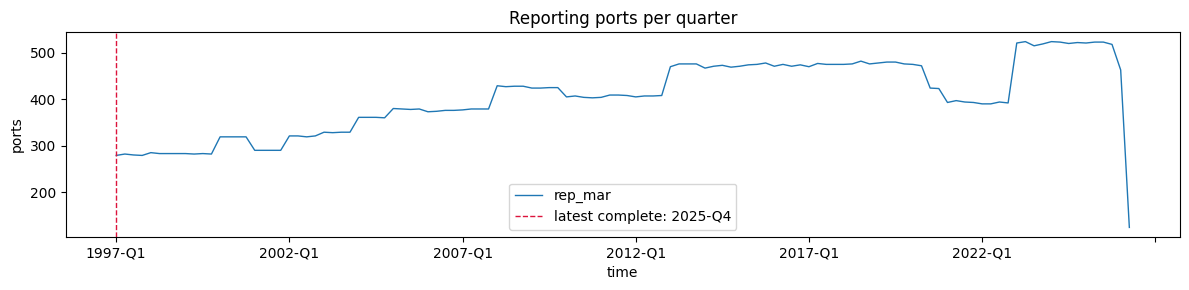

In [4]:
coverage = ports.groupby("time")["rep_mar"].nunique()


def is_complete(period, window=8, tolerance=0.9):
    """A quarter is complete if reporting ports >= tolerance * median of the prior window."""
    prior = coverage.loc[:period].iloc[:-1].tail(window)
    if len(prior) < 3:  # no baseline to judge against yet
        return True
    return coverage[period] >= tolerance * prior.median()


flags = pd.Series({p: is_complete(p) for p in coverage.index}, name="complete")
complete = flags[flags].index
incomplete = flags[~flags].index
latest = complete.max()

print(f"quarters complete   : {len(complete)} of {len(flags)}")
print(f"latest complete     : {latest} ({coverage[latest]} reporting ports)")
print("incomplete quarters (excluded from ranking):")
for period in list(incomplete)[-6:]:
    marker = "  <-- newest quarter" if period == flags.index.max() else ""
    print(f"  {period}: {coverage[period]} ports{marker}")

coverage.plot(figsize=(12, 3), title="Reporting ports per quarter", lw=1)
ax = plt.gca()
ax.axvline(latest, color="crimson", ls="--", lw=1, label=f"latest complete: {latest}")
ax.legend()
ax.set_ylabel("ports")
plt.tight_layout()

## 4. Top 10 ports — latest complete quarter

In [5]:
def top_ports(period, n=10):
    """Return the top-n ports for one period, with share of all reported throughput."""
    quarter = ports[ports["time"] == period]
    ranking = (
        quarter.groupby(["rep_mar", "geography"], as_index=False)["value"]
        .sum()
        .sort_values("value", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )
    ranking["million_tonnes"] = ranking["value"] / 1000
    ranking["share_pct"] = 100 * ranking["value"] / quarter["value"].sum()
    ranking.index = ranking.index + 1
    ranking.index.name = "rank"
    return ranking.drop(columns="value")


ranking = top_ports(latest)
print(f"Top 10 European ports by throughput, {latest} (million tonnes)")
ranking[["geography", "million_tonnes", "share_pct"]]

Top 10 European ports by throughput, 2025-Q4 (million tonnes)


,geography,million_tonnes,share_pct
rank,,,
1,Rotterdam,97.8,9.7
2,Antwerp-Bruges,56.0,5.5
3,Hamburg,24.5,2.4
4,Aliaga,22.2,2.2
5,HAROPA (Le Havre and Rouen),21.0,2.1
6,Amsterdam,20.7,2.1
7,Izmit,20.5,2.0
8,Gdansk,19.5,1.9
9,Algeciras,19.5,1.9


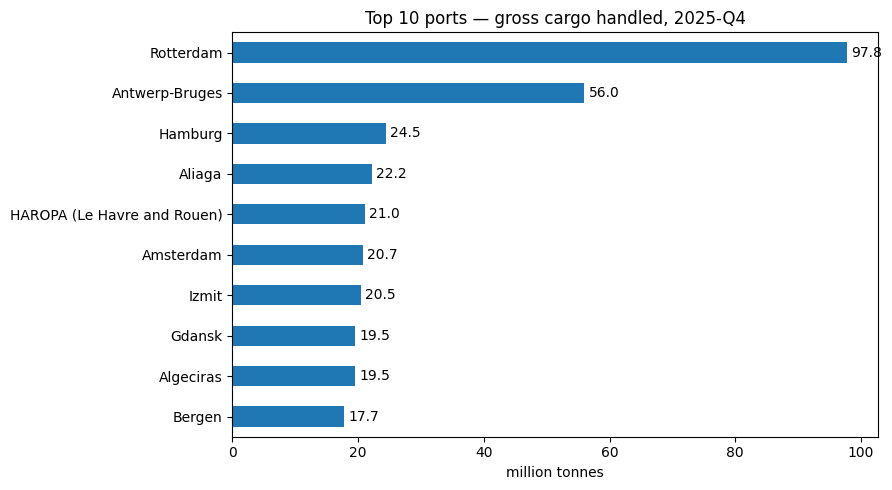

In [6]:
ax = (
    ranking.sort_values("million_tonnes")
    .plot.barh(x="geography", y="million_tonnes", legend=False, figsize=(9, 5), color="#1f77b4")
)
ax.set_xlabel("million tonnes")
ax.set_ylabel("")
ax.set_title(f"Top 10 ports — gross cargo handled, {latest}")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)
plt.tight_layout()

## 5. Top 10 over time

Same ports, quarterly series — this is the kind of target series a forecasting model would use.

In [7]:
top10 = list(ranking["rep_mar"])
history = ports[
    ports["rep_mar"].isin(top10)
    & ports["time"].isin(complete)
    & (ports["time"] >= "2015-Q1")
].copy()

print(f"{len(top10)} ports tracked, {history['time'].nunique()} complete quarters")

10 ports tracked, 39 complete quarters


geography,Rotterdam,Antwerp-Bruges,Hamburg,Aliaga,HAROPA (Le Havre and Rouen),Amsterdam,Izmit,Gdansk,Algeciras,Bergen
time,,,,,,,,,,
2024-Q1,99.9,62.9,23.8,21.6,20.2,19.3,20.8,17.7,21.0,15.9
2024-Q2,100.4,64.6,24.7,21.9,18.5,20.2,21.4,17.7,20.7,17.1
2024-Q3,98.5,57.8,24.3,19.6,18.7,19.1,20.1,18.0,20.4,16.9
2024-Q4,98.5,58.4,24.2,21.1,19.1,20.2,20.5,17.5,19.4,16.6
2025-Q1,94.9,59.9,24.5,22.6,18.4,18.2,20.0,16.4,19.6,16.8
2025-Q2,98.4,61.2,25.5,21.7,18.2,19.7,21.7,18.6,20.0,17.5
2025-Q3,99.0,56.3,25.3,21.0,20.5,19.9,20.5,20.9,19.1,17.0
2025-Q4,97.8,56.0,24.5,22.2,21.0,20.7,20.5,19.5,19.5,17.7


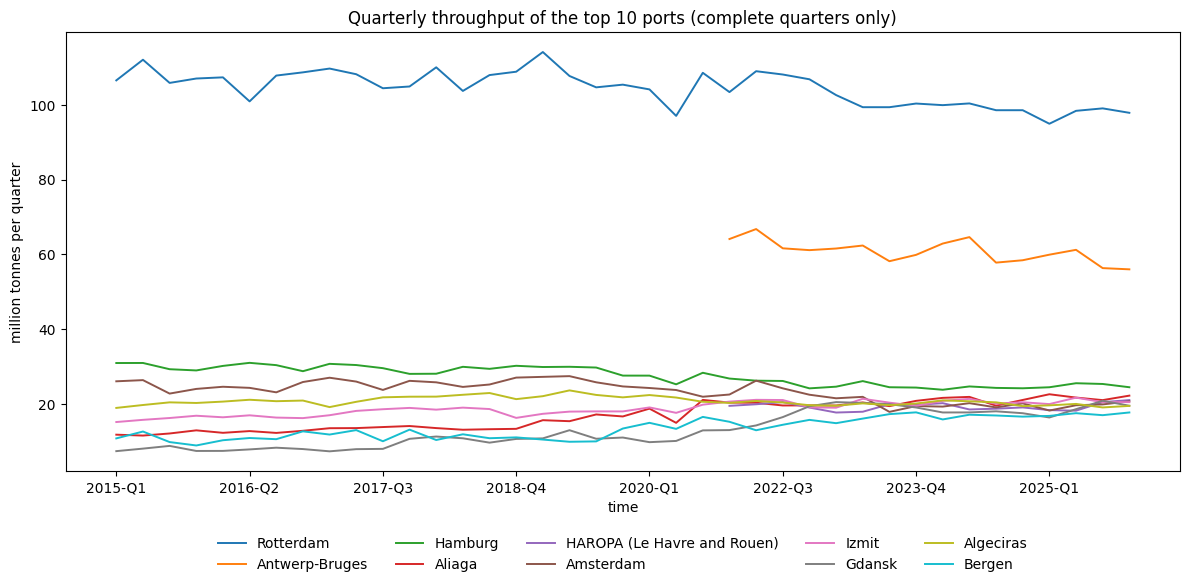

In [8]:
pivot = history.pivot_table(index="time", columns="geography", values="mt", aggfunc="sum")
pivot = pivot[[g for g in ranking["geography"] if g in pivot.columns]]

ax = pivot.plot(figsize=(12, 6), lw=1.4, colormap="tab10")
ax.set_ylabel("million tonnes per quarter")
ax.set_title("Quarterly throughput of the top 10 ports (complete quarters only)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)
plt.tight_layout()
pivot.tail(8)

## 6. Load-balance snapshot

How concentrated is European port throughput? Share of the top 10 vs. everyone else.

In [9]:
period_totals = (
    ports[ports["time"].isin(complete)]
    .groupby("time")["value"]
    .sum()
)
top10_share = (
    ports[ports["rep_mar"].isin(top10) & ports["time"].isin(complete)]
    .groupby("time")["value"]
    .sum()
    .div(period_totals)
    .mul(100)
)

summary = pd.DataFrame(
    {
        "total_Mt": period_totals / 1000,
        "top10_share_pct": top10_share,
        "n_ports": coverage,
    }
).dropna()

summary.tail(10)

,total_Mt,top10_share_pct,n_ports
time,,,
2023-Q3,984.3,32.2,515
2023-Q4,976.6,32.9,519
2024-Q1,976.0,33.1,524
2024-Q2,"1,010.2",32.4,523
2024-Q3,979.7,32.0,520
2024-Q4,980.8,32.2,522
2025-Q1,974.9,31.9,521
2025-Q2,"1,001.1",32.2,523
2025-Q3,"1,007.4",31.7,523


### Notes & caveats

* **Granularity** — `mar_go_qm` is quarterly tonnage. It works for structural load-balance
  analysis but is too coarse for daily traffic prediction; that needs AIS-derived vessel
  arrivals (Danish Maritime Authority dumps, Fintraffic port calls, aisstream.io).
* **`Antwerpen` vs `Antwerp-Bruges`** — Eurostat reports both codes; they overlap, so
  treat the Belgium series carefully when aggregating.
* **Lags** — annual data lands up to 16 months after the reference year; quarterly ~10 months.
* **Completeness** — always re-run the coverage check (§3) before ranking; it changes each release.
* **Units** — raw values are `THS_T`; the notebook converts to million tonnes (`/1000`).

**Next:** pull the annual `mar_go_aa` series for a 30-year backtest, then add AIS arrival
counts as a high-frequency target for the traffic prediction model.